In [7]:
#1. Use rasterio to open the GeoTIFF file. Print out the dimensions of the satellite image.Find the total bands available in the data and Coordinate Reference System (CRS)

import rasterio
import glob
import os

folder = r"C:\Mtech\Lab4"
tif_files = glob.glob(os.path.join(folder, "*.tif"))

print("Total GeoTIFF files:", len(tif_files))
print("\nAvailable bands:")

for file in tif_files:
    with rasterio.open(file) as src:
        print(
            os.path.basename(file),
            "→",
            "Width:", src.width,
            "Height:", src.height,
            "Bands:", src.count,
            "CRS:", src.crs
        )

Total GeoTIFF files: 19

Available bands:
BandStacked_img.tif → Width: 10980 Height: 10980 Bands: 13 CRS: EPSG:32644
clipped_img.tif → Width: 1000 Height: 1000 Bands: 13 CRS: EPSG:32644
NDVI_Map.tif → Width: 10980 Height: 10980 Bands: 1 CRS: EPSG:32644
NDVI_Map_Corrected.tif → Width: 10980 Height: 10980 Bands: 1 CRS: EPSG:32644
T44QQE_20260205T044859_B01.tif → Width: 1830 Height: 1830 Bands: 1 CRS: EPSG:32644
T44QQE_20260205T044859_B02.tif → Width: 10980 Height: 10980 Bands: 1 CRS: EPSG:32644
T44QQE_20260205T044859_B03.tif → Width: 10980 Height: 10980 Bands: 1 CRS: EPSG:32644
T44QQE_20260205T044859_B04.tif → Width: 10980 Height: 10980 Bands: 1 CRS: EPSG:32644
T44QQE_20260205T044859_B05.tif → Width: 5490 Height: 5490 Bands: 1 CRS: EPSG:32644
T44QQE_20260205T044859_B06.tif → Width: 5490 Height: 5490 Bands: 1 CRS: EPSG:32644
T44QQE_20260205T044859_B07.tif → Width: 5490 Height: 5490 Bands: 1 CRS: EPSG:32644
T44QQE_20260205T044859_B08.tif → Width: 10980 Height: 10980 Bands: 1 CRS: EPSG:3264

c:\Users\Dell\AppData\Local\Programs\Python\Python313\Lib\site-packages\rasterio\__init__.py:379: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)



 B02 (Blue)
Minimum : 0
Maximum : 7741
Mean    : 2319.5259925564283


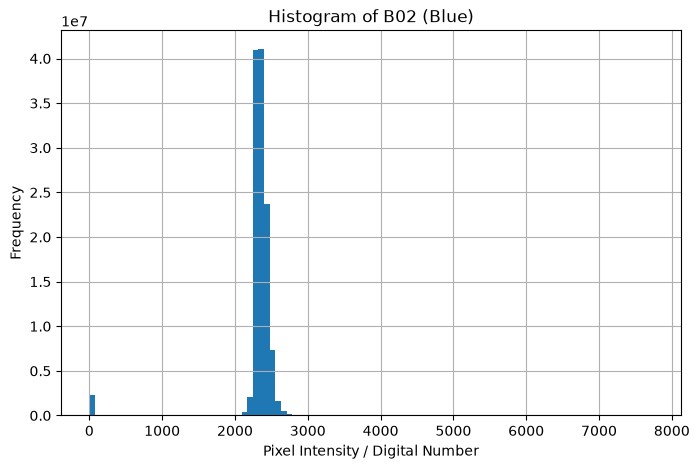


 B03 (Green)
Minimum : 0
Maximum : 7712
Mean    : 1973.7531861042266


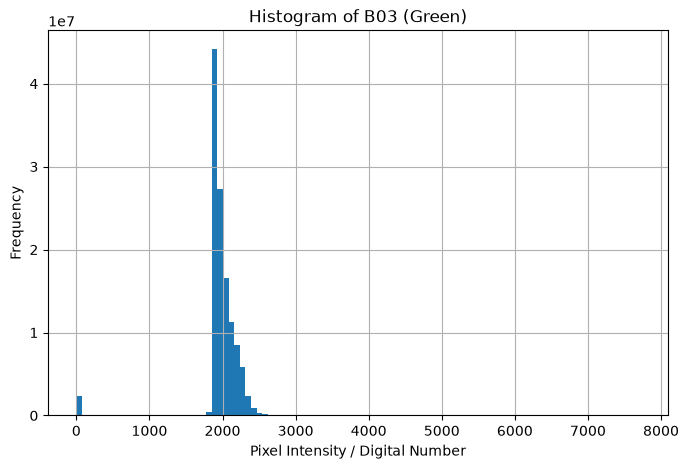


 B04 (Red)
Minimum : 0
Maximum : 8422
Mean    : 1744.7759591955567


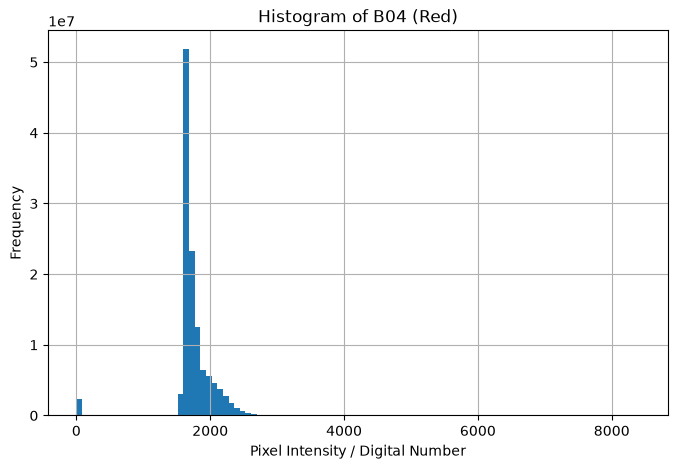

In [8]:
#2. Read this TIFF file and compute its minimum, maximum, mean across bands. Use matplotlib to plot a histogram of 3 selected spectral bands (3 histograms seperately).
import numpy as np
import matplotlib.pyplot as plt

band_files = {
    "B02 (Blue)": r"C:\Mtech\Lab4\T44QQE_20260205T044859_B02.tif",
    "B03 (Green)": r"C:\Mtech\Lab4\T44QQE_20260205T044859_B03.tif",
    "B04 (Red)": r"C:\Mtech\Lab4\T44QQE_20260205T044859_B04.tif"
}

for band_name, file_path in band_files.items():
    
    with rasterio.open(file_path) as src:
        image = src.read(1)
    minimum = np.min(image)
    maximum = np.max(image)
    mean = np.mean(image)

    print("\n", band_name)
    print("Minimum :", minimum)
    print("Maximum :", maximum)
    print("Mean    :", mean)

    plt.figure(figsize=(8, 5))
    plt.hist(image.flatten(), bins=100)
    plt.title(f"Histogram of {band_name}")
    plt.xlabel("Pixel Intensity / Digital Number")
    plt.ylabel("Frequency")
    plt.grid()
    plt.show()

In [9]:
#3. Do bandstacking by stacking all the bands of the satellite image and save it as a Geotiff file.

input_folder = r"C:\Mtech\Lab4"

output_file = os.path.join(input_folder, "BandStacked_img.tif")

band_names = [
    "B01", "B02", "B03", "B04",
    "B05", "B06", "B07", "B08",
    "B8A", "B09", "B10", "B11", "B12"
]

reference_file = os.path.join(
    input_folder,
    "T44QQE_20260205T044859_B02.tif"
)

with rasterio.open(reference_file) as ref:
    profile = ref.profile.copy()
    reference_crs = ref.crs
    reference_transform = ref.transform
    reference_width = ref.width
    reference_height = ref.height

profile.update(
    count=len(band_names),
    dtype="uint16",
    compress="lzw"
)

with rasterio.open(output_file, "w", **profile) as dst:

    for i, band in enumerate(band_names, start=1):

        file_path = os.path.join(
            input_folder,
            f"T44QQE_20260205T044859_{band}.tif"
        )

        with rasterio.open(file_path) as src:

            
            data = src.read(
                1,
                out_shape=(reference_height, reference_width),
                resampling=rasterio.enums.Resampling.bilinear
            )

            
            dst.write(data.astype("uint16"), i)

            print(f"Added Band {i}: {band}")

print("\nBand stacking completed!")
print("Saved file:", output_file)

Added Band 1: B01
Added Band 2: B02
Added Band 3: B03
Added Band 4: B04
Added Band 5: B05
Added Band 6: B06
Added Band 7: B07
Added Band 8: B08
Added Band 9: B8A
Added Band 10: B09
Added Band 11: B10
Added Band 12: B11


c:\Users\Dell\AppData\Local\Programs\Python\Python313\Lib\site-packages\rasterio\__init__.py:379: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)


Added Band 13: B12

Band stacking completed!
Saved file: C:\Mtech\Lab4\BandStacked_img.tif


In [10]:
import rasterio

stacked_file = r"C:\Mtech\Lab4\BandStacked_img.tif"

with rasterio.open(stacked_file) as src:
    print("Width       :", src.width)
    print("Height      :", src.height)
    print("Total Bands :", src.count)
    print("CRS         :", src.crs)
    print("Pixel Size  :", src.res)

Width       : 10980
Height      : 10980
Total Bands : 13
CRS         : EPSG:32644
Pixel Size  : (10.0, 10.0)


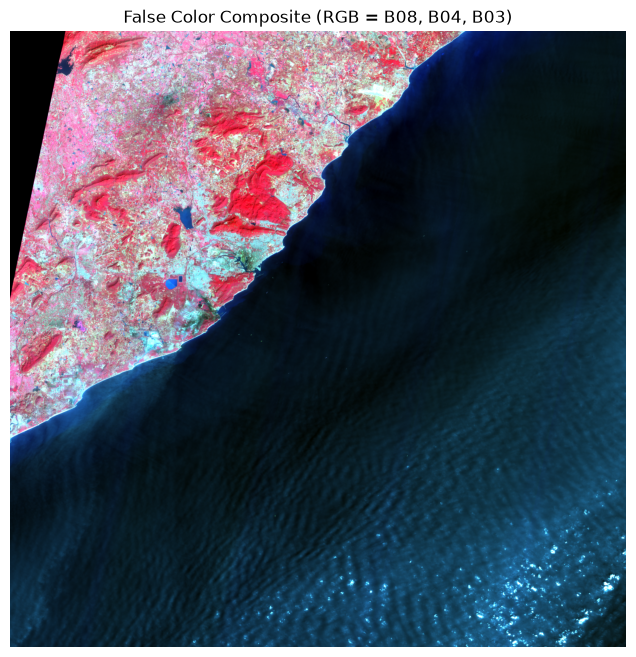

In [11]:
#4. Create and display True Color Composite (Natural Color, e.g., RGB mapped to Red,
#Green, Blue bands) and False Color Composite (Color Infrared, e.g., RGB mapped to NIR, Red, Green bands).


stacked_file = r"C:\Mtech\Lab4\BandStacked_img.tif"

with rasterio.open(stacked_file) as src:

    scale = 4

    height = src.height // scale
    width = src.width // scale

    B03 = src.read(
        3,
        out_shape=(height, width),
        resampling=rasterio.enums.Resampling.bilinear
    ).astype("float32")

    B04 = src.read(
        4,
        out_shape=(height, width),
        resampling=rasterio.enums.Resampling.bilinear
    ).astype("float32")

    B08 = src.read(
        8,
        out_shape=(height, width),
        resampling=rasterio.enums.Resampling.bilinear
    ).astype("float32")

def stretch(band):
    low = np.percentile(band, 2)
    high = np.percentile(band, 98)

    band = (band - low) / (high - low)

    return np.clip(band, 0, 1)

false_color = np.dstack([
    stretch(B08),
    stretch(B04),
    stretch(B03)
])

plt.figure(figsize=(10, 8))
plt.imshow(false_color)
plt.title("False Color Composite (RGB = B08, B04, B03)")
plt.axis("off")
plt.show()

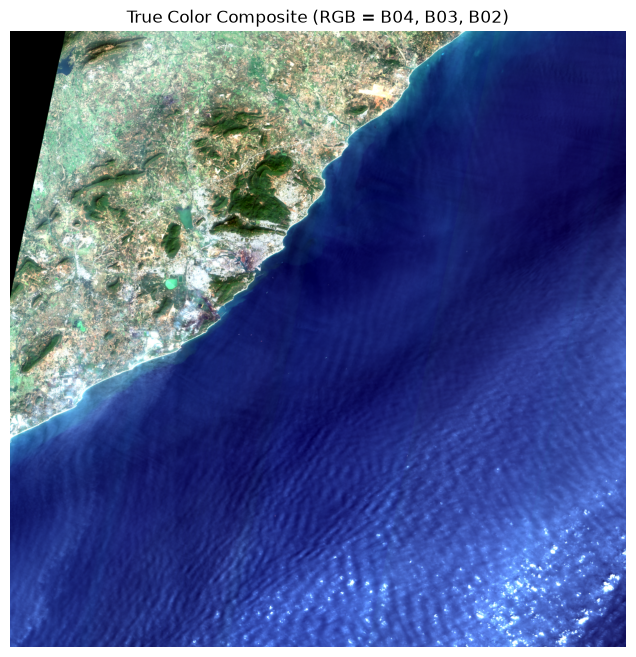

In [12]:

stacked_file = r"C:\Mtech\Lab4\BandStacked_img.tif"

with rasterio.open(stacked_file) as src:

    scale = 4

    height = src.height // scale
    width = src.width // scale


    B02 = src.read(
        2,
        out_shape=(height, width),
        resampling=rasterio.enums.Resampling.bilinear
    ).astype("float32")

    B03 = src.read(
        3,
        out_shape=(height, width),
        resampling=rasterio.enums.Resampling.bilinear
    ).astype("float32")

    B04 = src.read(
        4,
        out_shape=(height, width),
        resampling=rasterio.enums.Resampling.bilinear
    ).astype("float32")

def stretch(band):
    low = np.percentile(band, 2)
    high = np.percentile(band, 98)

    band = (band - low) / (high - low)

    return np.clip(band, 0, 1)



true_color = np.dstack([
    stretch(B04),
    stretch(B03),
    stretch(B02)
])


plt.figure(figsize=(10, 8))
plt.imshow(true_color)
plt.title("True Color Composite (RGB = B04, B03, B02)")
plt.axis("off")
plt.show()

Original Width : 10980
Original Height: 10980
AOI clipped successfully!
Saved as: C:\Mtech\Lab4\clipped_img.tif


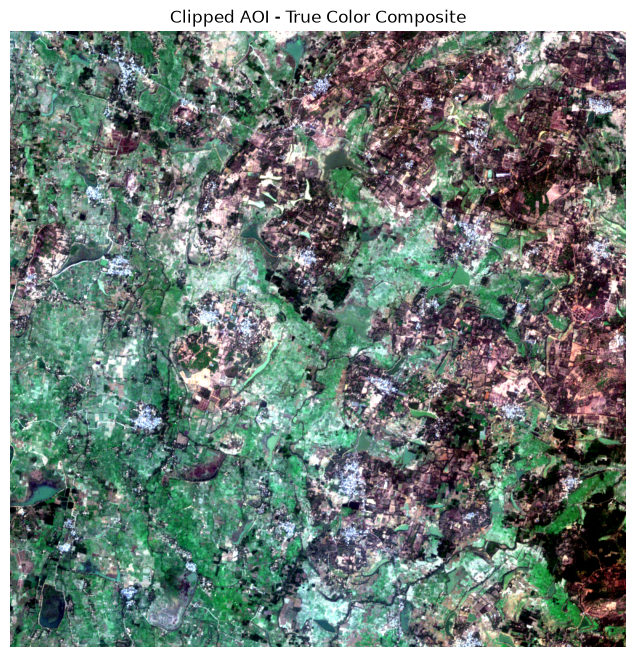

In [13]:
# 5. Clip a small area of interest from the satellite image and save it as a separate file

from rasterio.windows import Window

input_file = r"C:\Mtech\Lab4\BandStacked_img.tif"

output_file = r"C:\Mtech\Lab4\clipped_img.tif"

with rasterio.open(input_file) as src:

    print("Original Width :", src.width)
    print("Original Height:", src.height)

    col_start = 1000
    row_start = 1000


    width = 1000
    height = 1000

    window = Window(
        col_start,
        row_start,
        width,
        height
    )

    clipped_image = src.read(window=window)

    profile = src.profile.copy()

    profile.update({
        "height": height,
        "width": width,
        "transform": src.window_transform(window)
    })

    with rasterio.open(output_file, "w", **profile) as dst:
        dst.write(clipped_image)

print("AOI clipped successfully!")
print("Saved as:", output_file)


with rasterio.open(output_file) as src:

    B02 = src.read(2)   
    B03 = src.read(3)   
    B04 = src.read(4)   

def stretch(band):
    low = np.percentile(band, 2)
    high = np.percentile(band, 98)

    return np.clip(
        (band - low) / (high - low),
        0,
        1
    )

true_color_AOI = np.dstack([
    stretch(B04),
    stretch(B03),
    stretch(B02)
])


plt.figure(figsize=(10, 8))
plt.imshow(true_color_AOI)

plt.title("Clipped AOI - True Color Composite")
plt.xlabel("Column")
plt.ylabel("Row")

plt.axis("off")
plt.show()

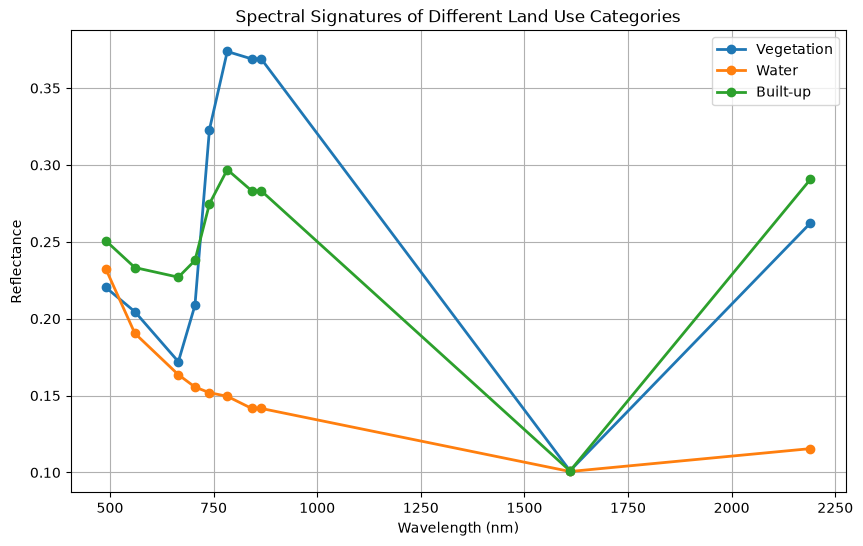

In [ ]:
"""6. Plot the spectral signature curve for different Land use categories (band wavelength vs.
reflectance). For example: Spectral plot for pixels with the following landuse categories :
Vegetation, water, urban, builtup."""

aoi_file = r"C:\Mtech\Lab4\BandStacked_img.tif"

bands = [2, 3, 4, 5, 6, 7, 8, 8, 11, 12]

wavelengths = [
    490, 560, 665, 705, 740,
    783, 842, 865, 1610, 2190
]

with rasterio.open(aoi_file) as src:

    locations = {
        "Vegetation": (3121, 4715),
        "Water": (4410,6944),
        "Built-up": (2933, 4928)
    }

    signatures = {}

    for category, (row, col) in locations.items():

        values = []

        for band in bands:

            window = rasterio.windows.Window(
                col - 2,
                row - 2,
                5,
                5
            )

            data = src.read(
                band,
                window=window
            ).astype("float32")

            mean_value = np.mean(data)
            reflectance = mean_value / 10000

            values.append(reflectance)

        signatures[category] = values

plt.figure(figsize=(10, 6))

for category, values in signatures.items():

    plt.plot(
        wavelengths,
        values,
        marker="o",
        linewidth=2,
        label=category
    )

plt.xlabel("Wavelength (nm)")
plt.ylabel("Reflectance")
plt.title("Spectral Signatures of Different Land Use Categories")
plt.legend()
plt.grid()
plt.show()

INPUT FILES
Red B04:
T44QQE_20260205T044859_B04.tif

NIR B08:
T44QQE_20260205T044859_B08.tif

IMAGE INFORMATION
Width       : 10980
Height      : 10980
Resolution  : 10.0 m x 10.0 m
CRS         : EPSG:32644
B04 NoData  : None
B08 NoData  : None
Pixel area  : 100.0 m²

PROCESSING IMAGE...

Processing completed successfully!

NDVI RESULTS
Minimum NDVI : -0.7778
Maximum NDVI : 0.9995
Mean NDVI    : -0.0071

CLASSIFICATION RESULTS
NDVI Threshold       : 0.3
Valid pixels         : 118227943
No vegetation pixels : 116083118
Vegetation pixels    : 2144825

VEGETATED AREA
Pixel area: 100.0 m²
Vegetated area: 214482500.0 m²
Vegetated area: 21448.25 hectares
Vegetated area: 214.4825 km²
Vegetation percentage: 1.81 %

Creating NDVI display...


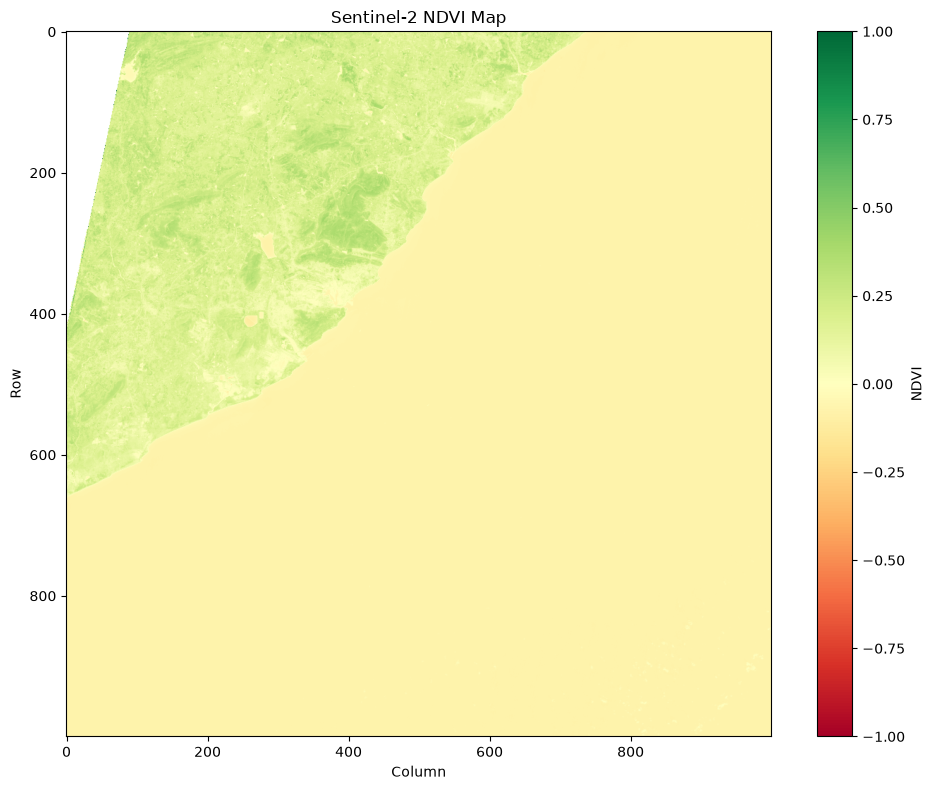

Creating vegetation map display...


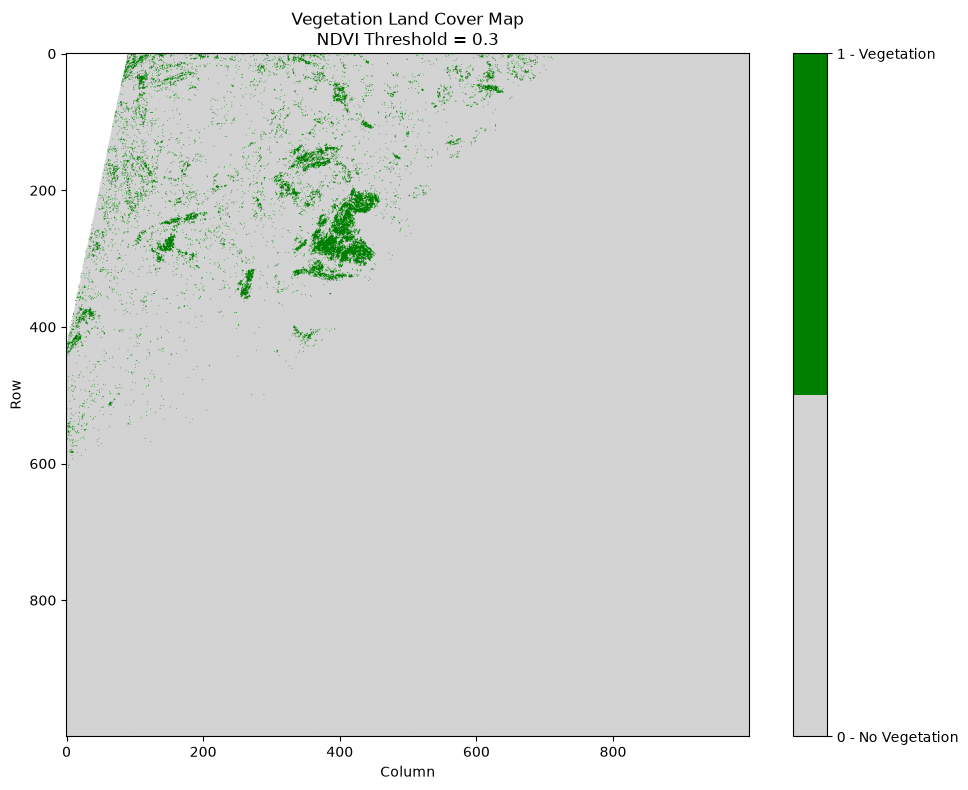


OUTPUT FILES

NDVI Map:
C:\Mtech\Lab4\NDVI_Map_Corrected.tif

Vegetation Map:
C:\Mtech\Lab4\Vegetation_Map_Corrected_0_1.tif

CLASS VALUES
0   = No Vegetation
1   = Vegetation
255 = NoData / Outside valid image area

DONE


In [ ]:
"""7. Compute the NDVI of the image and using band thresholding (on NDVI values)
compute the area of vegetated land in the image. Create a map of the vegetated
landcover in a map layout (Plot the map with band values containing 0-No vegetation,
1-Vegetation)."""
from matplotlib.colors import ListedColormap

folder = r"C:\Mtech\Lab4"

red_files = glob.glob(
    os.path.join(folder, "*_B04.tif")
)

nir_files = glob.glob(
    os.path.join(folder, "*_B08.tif")
)


if len(red_files) == 0:
    raise FileNotFoundError(
        "B04 file not found in C:\\Mtech\\Lab4"
    )

if len(nir_files) == 0:
    raise FileNotFoundError(
        "B08 file not found in C:\\Mtech\\Lab4"
    )


red_file = red_files[0]
nir_file = nir_files[0]


print("=" * 65)
print("INPUT FILES")
print("=" * 65)

print("Red B04:")
print(os.path.basename(red_file))

print("\nNIR B08:")
print(os.path.basename(nir_file))


NDVI_THRESHOLD = 0.3


with rasterio.open(red_file) as red_src:

    width = red_src.width
    height = red_src.height

    transform = red_src.transform
    crs = red_src.crs

    pixel_width = abs(transform.a)
    pixel_height = abs(transform.e)

    red_nodata = red_src.nodata

    red_profile = red_src.profile.copy()


with rasterio.open(nir_file) as nir_src:

    if nir_src.width != width or nir_src.height != height:

        raise ValueError(
            "B04 and B08 have different dimensions."
        )

    nir_nodata = nir_src.nodata


print("\n" + "=" * 65)
print("IMAGE INFORMATION")
print("=" * 65)

print("Width       :", width)
print("Height      :", height)

print("Resolution  :",
      pixel_width,
      "m x",
      pixel_height,
      "m")

print("CRS         :", crs)

print("B04 NoData  :", red_nodata)
print("B08 NoData  :", nir_nodata)

print("Pixel area  :",
      pixel_width * pixel_height,
      "m²")


ndvi_output = os.path.join(
    folder,
    "NDVI_Map_Corrected.tif"
)

vegetation_output = os.path.join(
    folder,
    "Vegetation_Map_Corrected_0_1.tif"
)


ndvi_profile = red_profile.copy()

ndvi_profile.update(
    driver="GTiff",
    dtype=rasterio.float32,
    count=1,
    nodata=-9999,
    compress="lzw"
)


vegetation_profile = red_profile.copy()

vegetation_profile.update(
    driver="GTiff",
    dtype=rasterio.uint8,
    count=1,
    nodata=255,
    compress="lzw"
)


vegetation_pixels = 0
no_vegetation_pixels = 0
valid_pixels = 0

ndvi_sum = 0

ndvi_min = 999
ndvi_max = -999


print("\n" + "=" * 65)
print("PROCESSING IMAGE...")
print("=" * 65)


with rasterio.open(red_file) as red_src, \
     rasterio.open(nir_file) as nir_src, \
     rasterio.open(ndvi_output, "w", **ndvi_profile) as ndvi_dst, \
     rasterio.open(vegetation_output, "w", **vegetation_profile) as veg_dst:


    for ji, window in red_src.block_windows(1):

        red = red_src.read(
            1,
            window=window
        ).astype(np.float32)


        nir = nir_src.read(
            1,
            window=window
        ).astype(np.float32)

        red_mask = red_src.read_masks(
            1,
            window=window
        )

        nir_mask = nir_src.read_masks(
            1,
            window=window
        )

        valid = (
            (red_mask > 0) &
            (nir_mask > 0)
        )

        valid &= (
            red > 0
        ) & (
            nir > 0
        )

        denominator = nir + red

        valid &= denominator != 0


        ndvi_block = np.full(
            red.shape,
            np.nan,
            dtype=np.float32
        )


        ndvi_block[valid] = (
            (nir[valid] - red[valid])
            /
            (nir[valid] + red[valid])
        )

        valid &= (
            ndvi_block >= -1
        ) & (
            ndvi_block <= 1
        )

        valid_ndvi = ndvi_block[valid]


        if valid_ndvi.size > 0:

            valid_pixels += valid_ndvi.size

            ndvi_sum += float(
                np.sum(valid_ndvi)
            )

            ndvi_min = min(
                ndvi_min,
                float(np.min(valid_ndvi))
            )

            ndvi_max = max(
                ndvi_max,
                float(np.max(valid_ndvi))
            )

        vegetation_block = np.full(
            red.shape,
            255,
            dtype=np.uint8
        )

        vegetation_block[
            valid &
            (ndvi_block <= NDVI_THRESHOLD)
        ] = 0

        vegetation_block[
            valid &
            (ndvi_block > NDVI_THRESHOLD)
        ] = 1

        vegetation_pixels += np.sum(
            vegetation_block == 1
        )


        no_vegetation_pixels += np.sum(
            vegetation_block == 0
        )

        ndvi_save = np.where(
            valid,
            ndvi_block,
            -9999
        ).astype(np.float32)


        ndvi_dst.write(
            ndvi_save,
            1,
            window=window
        )

        veg_dst.write(
            vegetation_block,
            1,
            window=window
        )


print("\nProcessing completed successfully!")


if valid_pixels > 0:

    mean_ndvi = ndvi_sum / valid_pixels

else:

    mean_ndvi = np.nan

pixel_area = (
    pixel_width *
    pixel_height
)


vegetated_area_m2 = (
    vegetation_pixels *
    pixel_area
)


vegetated_area_hectares = (
    vegetated_area_m2 /
    10000
)


vegetated_area_km2 = (
    vegetated_area_m2 /
    1000000
)

if valid_pixels > 0:

    vegetation_percentage = (
        vegetation_pixels /
        valid_pixels
    ) * 100

else:

    vegetation_percentage = 0

print("\n" + "=" * 65)
print("NDVI RESULTS")
print("=" * 65)

print(
    "Minimum NDVI :",
    round(ndvi_min, 4)
)

print(
    "Maximum NDVI :",
    round(ndvi_max, 4)
)

print(
    "Mean NDVI    :",
    round(mean_ndvi, 4)
)


print("\n" + "=" * 65)
print("CLASSIFICATION RESULTS")
print("=" * 65)

print(
    "NDVI Threshold       :",
    NDVI_THRESHOLD
)

print(
    "Valid pixels         :",
    valid_pixels
)

print(
    "No vegetation pixels :",
    no_vegetation_pixels
)

print(
    "Vegetation pixels    :",
    vegetation_pixels
)


print("\n" + "=" * 65)
print("VEGETATED AREA")
print("=" * 65)

print(
    "Pixel area:",
    pixel_area,
    "m²"
)

print(
    "Vegetated area:",
    round(
        vegetated_area_m2,
        2
    ),
    "m²"
)

print(
    "Vegetated area:",
    round(
        vegetated_area_hectares,
        2
    ),
    "hectares"
)

print(
    "Vegetated area:",
    round(
        vegetated_area_km2,
        4
    ),
    "km²"
)

print(
    "Vegetation percentage:",
    round(
        vegetation_percentage,
        2
    ),
    "%"
)

print("\nCreating NDVI display...")


with rasterio.open(
    ndvi_output
) as src:

    ndvi_display = src.read(
        1,
        out_shape=(
            1,
            1000,
            1000
        ),
        resampling=rasterio.enums.Resampling.average
    )

ndvi_display = np.where(
    ndvi_display == -9999,
    np.nan,
    ndvi_display
)


plt.figure(
    figsize=(10, 8)
)


plt.imshow(
    ndvi_display,
    cmap="RdYlGn",
    vmin=-1,
    vmax=1
)


plt.colorbar(
    label="NDVI"
)


plt.title(
    "Sentinel-2 NDVI Map"
)


plt.xlabel(
    "Column"
)

plt.ylabel(
    "Row"
)


plt.tight_layout()

plt.show()

print("Creating vegetation map display...")


with rasterio.open(
    vegetation_output
) as src:

    vegetation_display = src.read(
        1,
        out_shape=(
            1,
            1000,
            1000
        ),
        resampling=rasterio.enums.Resampling.nearest
    )

vegetation_display_masked = np.ma.masked_equal(
    vegetation_display,
    255
)


plt.figure(
    figsize=(10, 8)
)


cmap = ListedColormap([
    "lightgray",
    "green"
])


plt.imshow(
    vegetation_display_masked,
    cmap=cmap,
    vmin=0,
    vmax=1
)

cbar = plt.colorbar(
    ticks=[0, 1]
)


cbar.ax.set_yticklabels([
    "0 - No Vegetation",
    "1 - Vegetation"
])


plt.title(
    "Vegetation Land Cover Map\n"
    "NDVI Threshold = " +
    str(NDVI_THRESHOLD)
)


plt.xlabel(
    "Column"
)

plt.ylabel(
    "Row"
)


plt.tight_layout()

plt.show()


print("\n" + "=" * 65)
print("OUTPUT FILES")
print("=" * 65)

print(
    "\nNDVI Map:"
)

print(
    ndvi_output
)


print(
    "\nVegetation Map:"
)

print(
    vegetation_output
)


print("\n" + "=" * 65)
print("CLASS VALUES")
print("=" * 65)

print(
    "0   = No Vegetation"
)

print(
    "1   = Vegetation"
)

print(
    "255 = NoData / Outside valid image area"
)


print("\n" + "=" * 65)
print("DONE")
print("=" * 65)